### Versión mejorada de generación de sCMBs sobre dataser CSIRO sujetos sanos

In [21]:
import os
import glob
import numpy as np
import nibabel as nib
import json
from scipy.ndimage import binary_erosion, generate_binary_structure, rotate
from skimage.transform import downscale_local_mean
import time


In [22]:
# ==========================================
# 1. CONFIGURACIÓN MASIVA (nnU-Net v2)
# ==========================================
# Ruta origen (AIBL limpio)
INPUT_ROOT_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/NoCMBSubject/data"

# Ruta destino: IMPORTANTE usar formato DatasetXXX_Nombre
DATASET_NAME = "Dataset112_SyntheticCMB"
NNUNET_RAW_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/nnUNet_raw" 
OUTPUT_DIR = os.path.join(NNUNET_RAW_DIR, DATASET_NAME)

# Parámetros
NUM_LESIONS_PER_SCAN = 20
RANDOM_SEED = 42

# Crear estructura de carpetas nnU-Net v2
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(os.path.join(OUTPUT_DIR, "imagesTr"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "labelsTr"), exist_ok=True)


In [23]:
# ==========================================
# 2. MOTOR MATEMÁTICO (Momeni Validado)
# ==========================================
def generate_momeni_gaussian(target_volume_mm3, voxel_size_mm, oversample=10):
    K = 1.175 
    term = (3 * target_volume_mm3) / (4 * np.pi * (K**3))
    sigma_t_mm = np.cbrt(term)
    
    # --- MEJORA 4: MAYOR ANISOTROPÍA ---
    # Aumentamos el rango de variación de los ejes para que no siempre sean casi-esferas
    rmin, rmax = 0.4, 1.2 # Antes 0.5, 0.9
    sigma_x_mm = sigma_t_mm * np.random.uniform(rmin, rmax)
    sigma_y_mm = sigma_t_mm * np.random.uniform(rmin, rmax)
    # sigma_z se calcula para mantener el volumen constante, lo cual es correcto
    sigma_z_mm = (sigma_t_mm**3) / (sigma_x_mm * sigma_y_mm)

    hr_vx_size = np.array(voxel_size_mm) / oversample
    sx_px = sigma_x_mm / hr_vx_size[0]
    sy_px = sigma_y_mm / hr_vx_size[1]
    sz_px = sigma_z_mm / hr_vx_size[2]
    
    max_sigma = max(sx_px, sy_px, sz_px)
    grid_size = int(max_sigma * 6) + 1
    if grid_size % 2 == 0: grid_size += 1
    
    cx, cy, cz = grid_size // 2, grid_size // 2, grid_size // 2
    
    x = np.arange(grid_size) - cx
    y = np.arange(grid_size) - cy
    z = np.arange(grid_size) - cz
    xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')
    
    exponent = - ( (xx**2)/(2*sx_px**2) + (yy**2)/(2*sy_px**2) + (zz**2)/(2*sz_px**2) )
    gaussian = np.exp(exponent)
    
    angle_x = np.random.uniform(-30, 30)
    angle_y = np.random.uniform(-30, 30)
    angle_z = np.random.uniform(-30, 30)
    
    img_rot = rotate(gaussian, angle_x, axes=(0,1), reshape=False, order=1)
    img_rot = rotate(img_rot, angle_y, axes=(1,2), reshape=False, order=1)
    img_rot = rotate(img_rot, angle_z, axes=(0,2), reshape=False, order=1)
    
    low_res_blob = downscale_local_mean(img_rot, (oversample, oversample, oversample))
    if low_res_blob.max() > 0:
        low_res_blob /= low_res_blob.max()
        
    return low_res_blob





def implant_and_label(image_data, label_data, center, volume_mm3, voxel_dims, strength):
    x, y, z = center
    lesion_pattern = generate_momeni_gaussian(volume_mm3, voxel_dims, oversample=10)
    
    p_shape = lesion_pattern.shape
    dx, dy, dz = p_shape[0]//2, p_shape[1]//2, p_shape[2]//2
    x_s, x_e = x - dx, x - dx + p_shape[0]
    y_s, y_e = y - dy, y - dy + p_shape[1]
    z_s, z_e = z - dz, z - dz + p_shape[2]
    
    if x_s < 0 or x_e > image_data.shape[0] or \
       y_s < 0 or y_e > image_data.shape[1] or \
       z_s < 0 or z_e > image_data.shape[2]:
        return image_data, label_data
    
    roi_img = image_data[x_s:x_e, y_s:y_e, z_s:z_e]
    if roi_img.shape != lesion_pattern.shape:
        lesion_pattern = lesion_pattern[:roi_img.shape[0], :roi_img.shape[1], :roi_img.shape[2]]
    
    # --- MEJORA 1: RUIDO TEXTURAL INTERNO ---
    # Las rCMBs reales no son uniformes. Añadimos un ruido gaussiano leve 
    # al patrón antes de la resta para simular textura de susceptibilidad.
    noise = np.random.normal(0, 0.05, lesion_pattern.shape)
    lesion_pattern_noisy = np.clip(lesion_pattern + noise, 0, 1)
    
    # --- MEJORA 2: AJUSTE DE ATENUACIÓN (STRENGTH) ---
    # Usamos el 'strength' calculado fuera para que cubra el rango de las FNs (0.4 - 0.9)
    mask_multiplier = 1 - (lesion_pattern_noisy * strength)

    # [NUEVO] Forzamos que el núcleo de la lesión sea un poco más sólido
    # Esto evita ratios de 0.95 que son básicamente aire
    mask_multiplier = np.clip(mask_multiplier, 0.02, 1.0)

    image_data[x_s:x_e, y_s:y_e, z_s:z_e] = roi_img * mask_multiplier
    
    # La máscara de ground truth (Label) debe ser un poco más estricta 
    # que la caída de señal para que la red no aprenda bordes difusos como lesión
    roi_label = label_data[x_s:x_e, y_s:y_e, z_s:z_e]
    lesion_mask_binary = (lesion_pattern >= 0.5).astype(int)
    label_data[x_s:x_e, y_s:y_e, z_s:z_e] = np.maximum(roi_label, lesion_mask_binary)
    
    return image_data, label_data


def get_brain_safety_mask_robust(img_data, erosion_iters=5):
    """
    Usa Multi-Otsu para calcular dinámicamente el umbral de tejido.
    Evita pintar en ventrículos (líquido) o fondo.
    """
    # Aplanamos y quitamos ceros para calcular el umbral
    data_vector = img_data[img_data > 10].ravel()
    
    try:
        if len(data_vector) < 1000:
            raise ValueError("Imagen vacía")
            
        # 3 Clases: Fondo(0) | Líquido(1) | Tejido(2)
        thresholds = threshold_multiotsu(data_vector, classes=3)
        tissue_threshold = thresholds[1] # Corte Líquido vs Tejido
        
    except Exception:
        # Fallback de seguridad: Media simple si Otsu falla
        tissue_threshold = np.mean(data_vector) if len(data_vector) > 0 else 20
        print(f"   [!] Fallback Threshold: {tissue_threshold:.2f}")

    # Binarizar con el umbral inteligente
    binary = img_data > tissue_threshold
    
    # Erosión: Alejarse de los bordes (Cráneo y Ventrículos)
    struct = generate_binary_structure(3, 1) 
    eroded = binary_erosion(binary, structure=struct, iterations=erosion_iters)
    
    return eroded, tissue_threshold


# ==========================================
# 3. EJECUCIÓN DEL PIPELINE MASIVO
# ==========================================
print(f"Iniciando Pipeline Masivo...")
nifti_files = glob.glob(os.path.join(INPUT_ROOT_DIR, "**/*.nii.gz"), recursive=True)
print(f"Archivos encontrados: {len(nifti_files)}")

np.random.seed(RANDOM_SEED)

# Contador para el dataset.json
train_files_count = 0

for idx, file_path in enumerate(nifti_files):
    start_time = time.time()
    filename = os.path.basename(file_path)
    # ID simple para nnU-Net: CSIRO_001, CSIRO_002...
    subject_id = f"CSIRO_{idx+1:03d}" 
    
    print(f"\n[{idx+1}/{len(nifti_files)}] {filename} -> {subject_id}")
    
    try:
        nii = nib.load(file_path)
        data_img = nii.get_fdata().astype(float)
        data_label = np.zeros(data_img.shape, dtype=np.uint8)
        voxel_dims = nii.header.get_zooms()

        safety_mask, used_thresh = get_brain_safety_mask_robust(data_img)
        valid_coords = np.argwhere(safety_mask)
        
        print(f"   -> Umbral calculado: {used_thresh:.2f} | Vóxeles seguros: {len(valid_coords)}")
        
        if len(valid_coords) < NUM_LESIONS_PER_SCAN:
            print(f"SKIP: Pocos vóxeles seguros tras umbral estricto.")
            continue
            
        random_indices = np.random.choice(len(valid_coords), size=NUM_LESIONS_PER_SCAN, replace=False)
        selected_coords = valid_coords[random_indices]
        

        for coord in selected_coords:
            # Volumen: Mantenemos la triangular, es una buena aproximación
            vol_rnd = np.random.triangular(left=0.8, mode=2.5, right=15.0)
            
            # --- MEJORA 3: MUESTREO DE INTENSIDAD BASADO EN DATOS ---
            # Tus TPs están en 55 y tus FNs en 105+. 
            # Si el background medio es ~200, un strength de 0.5 da intensidad 100.
            # Un strength de 0.9 da intensidad 20.
            # Queremos una distribución que cubra ambos:
            # Definimos: Mínimo 0.60 (lesión tenue), Moda 0.80 (lesión estándar), Máximo 0.98 (agujero negro)
           
            # --- AJUSTE PARA TRIAL 2.1 ---
            # Objetivo: Desplazar la media del ratio hacia el 0.27
            # Subimos el suelo (left) para evitar las lesiones "invisibles"
            # Subimos la moda (mode) para centrar el grueso en el ratio real
            str_rnd = np.random.triangular(left=0.70, mode=0.80, right=0.98)
            
            data_img, data_label = implant_and_label(data_img, data_label, coord, vol_rnd, voxel_dims, str_rnd)


        # --- GUARDADO NNUNET ---
        out_name_img = f"{subject_id}_0000.nii.gz" # Canal 0
        out_name_lbl = f"{subject_id}.nii.gz"      # Label
        
        path_img = os.path.join(OUTPUT_DIR, "imagesTr", out_name_img)
        path_lbl = os.path.join(OUTPUT_DIR, "labelsTr", out_name_lbl)
        
        nib.save(nib.Nifti1Image(data_img, nii.affine, nii.header), path_img)
        nib.save(nib.Nifti1Image(data_label, nii.affine, nii.header), path_lbl)
        
        train_files_count += 1
        elapsed = time.time() - start_time
        print(f"Ok ({elapsed:.2f}s)")
        
    except Exception as e:
        print(f"ERROR: {e}")

# ==========================================
# 4. GENERACIÓN AUTOMÁTICA DATASET.JSON (v2)
# ==========================================
print("-" * 50)
print("Generando dataset.json para nnU-Net v2...")

json_dict = {
    "channel_names": {
        "0": "SWI"  # O la modalidad que sea (T2*, T1, etc.)
    },
    "labels": {
        "background": 0,
        "CMB": 1
    },
    "numTraining": train_files_count,
    "file_ending": ".nii.gz",
    "name": DATASET_NAME,
    "reference": "Synthetic Data generated via Momeni method",
    "release": "1.0",
    "description": "Synthetic Microbleeds dataset for TFM",
    "overwrite_image_reader_writer": "SimpleITKIO"
}

json_path = os.path.join(OUTPUT_DIR, "dataset.json")
with open(json_path, 'w') as f:
    json.dump(json_dict, f, indent=4)

print(f"dataset.json creado en: {json_path}")
print("-" * 50)
print(f"TODO LISTO. Dataset preparado en: {OUTPUT_DIR}")
print(" -> Siguiente paso: nnUNetv2_plan_and_preprocess")

Iniciando Pipeline Masivo...
Archivos encontrados: 313

[1/313] 2_T2_MRI_SWI_BFC_50mm_HM.nii.gz -> CSIRO_001
   [!] Fallback Threshold: 333.04
   -> Umbral calculado: 333.04 | Vóxeles seguros: 184254
Ok (2.01s)

[2/313] 13_T2_MRI_SWI_BFC_50mm_HM.nii.gz -> CSIRO_002
   [!] Fallback Threshold: 334.69
   -> Umbral calculado: 334.69 | Vóxeles seguros: 168118
Ok (1.79s)

[3/313] 13_T3_MRI_SWI_BFC_50mm_HM.nii.gz -> CSIRO_003
   [!] Fallback Threshold: 332.36
   -> Umbral calculado: 332.36 | Vóxeles seguros: 179458
Ok (3.92s)

[4/313] 14_T2_MRI_SWI_BFC_50mm_HM.nii.gz -> CSIRO_004
   [!] Fallback Threshold: 338.21
   -> Umbral calculado: 338.21 | Vóxeles seguros: 194391
Ok (2.15s)

[5/313] 14_T3_MRI_SWI_BFC_50mm_HM.nii.gz -> CSIRO_005
   [!] Fallback Threshold: 341.15
   -> Umbral calculado: 341.15 | Vóxeles seguros: 193849
Ok (2.72s)

[6/313] 14_T4_MRI_SWI_BFC_50mm_HM.nii.gz -> CSIRO_006
   [!] Fallback Threshold: 339.17
   -> Umbral calculado: 339.17 | Vóxeles seguros: 236926
Ok (2.60s)

[7/

### Análisis de las CMBs generadas en este trial 2 con respecto a las reales

Analizando sCMBs del Trial 2...


/tmp/ipykernel_82972/1316537267.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tipo', y='intensidad', data=df_comparativa, palette='Set2')


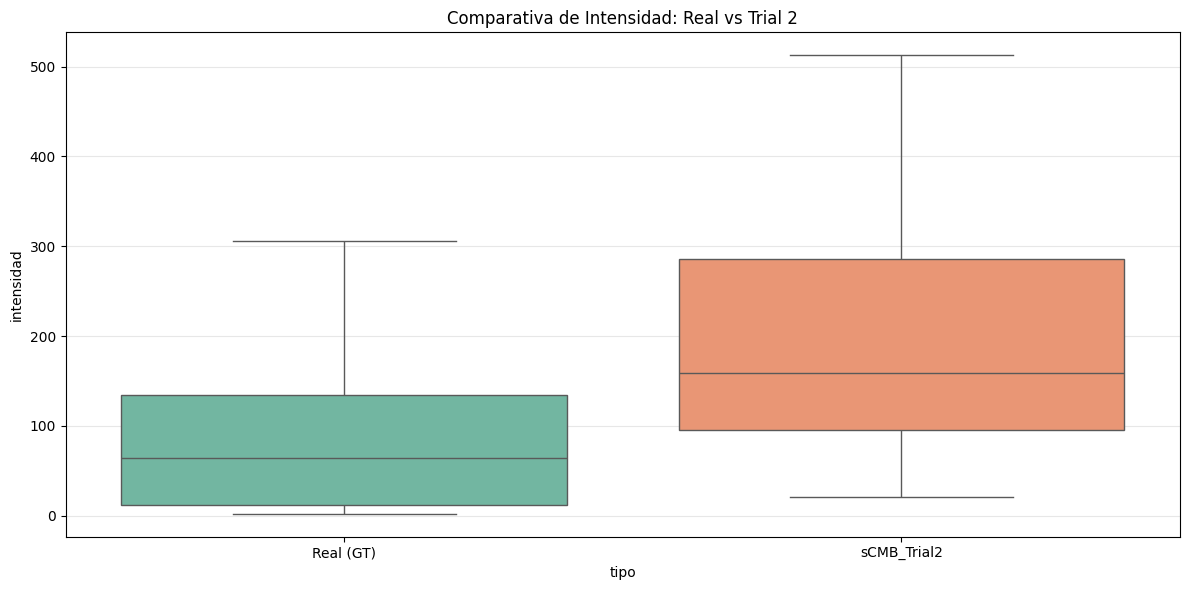


--- RESUMEN ESTADÍSTICO ---
             count        mean         std        min        25%         50%  \
tipo                                                                           
Real (GT)    146.0   84.863156   81.772218   2.292336  11.463897   63.879171   
sCMB_Trial2  400.0  195.225077  114.756628  20.804192  95.769279  158.380928   

                    75%         max  
tipo                                 
Real (GT)    134.966003  305.942841  
sCMB_Trial2  286.342331  512.704834  


In [24]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import label, regionprops

# ========================= CONFIGURACIÓN =========================
# Dataset NUEVO (Trial 2)
NEW_DATASET_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/nnUNet_raw/Dataset112_SyntheticCMB"
# Resultados del Trial 1 (los que me pasaste antes)
REAL_STATS_CSV = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/check2_nnUNet_results_test_with_rCMBs/analisis_intensidades_diagnostico.csv"

def analyze_synthetic_dataset(dataset_dir, num_samples=20):
    img_dir = os.path.join(dataset_dir, "imagesTr")
    lbl_dir = os.path.join(dataset_dir, "labelsTr")
    
    label_files = os.listdir(lbl_dir)[:num_samples]
    synth_stats = []

    for lbl_name in label_files:
        img_name = lbl_name.replace(".nii.gz", "_0000.nii.gz")
        
        img_data = nib.load(os.path.join(img_dir, img_name)).get_fdata()
        lbl_data = nib.load(os.path.join(lbl_dir, lbl_name)).get_fdata()
        
        props = regionprops(label(lbl_data))
        for p in props:
            # Centroide de la lesión sintética
            cx, cy, cz = map(int, p.centroid)
            val_centro = img_data[cx, cy, cz]
            
            synth_stats.append({
                'tipo': 'sCMB_Trial2',
                'intensidad': val_centro,
                'size_voxels': p.area
            })
    return pd.DataFrame(synth_stats)

# 1. Cargar datos reales previos
df_real = pd.read_csv(REAL_STATS_CSV)
# Solo nos quedamos con rCMBs reales (TP + FN)
df_real_total = df_real[df_real['tipo'].isin(['TP', 'FN'])].copy()
df_real_total['tipo'] = 'Real (GT)'

# 2. Analizar el nuevo Dataset sintético
print("Analizando sCMBs del Trial 2...")
df_synth = analyze_synthetic_dataset(NEW_DATASET_DIR)

# 3. Combinar y Graficar
df_comparativa = pd.concat([df_real_total, df_synth], ignore_index=True)

plt.figure(figsize=(12, 6))

# Subplot 1: Intensidades
sns.boxplot(x='tipo', y='intensidad', data=df_comparativa, palette='Set2')
plt.title('Comparativa de Intensidad: Real vs Trial 2')
plt.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

# Resumen numérico
print("\n--- RESUMEN ESTADÍSTICO ---")
print(df_comparativa.groupby('tipo')['intensidad'].describe())

Calculando ratios para el dataset Real...
Calculando ratios para el dataset Sintético (Trial 2)...


/tmp/ipykernel_82972/1856381522.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tipo', y='ratio_intensidad', data=df_comp, palette='Set1')



--- ESTADÍSTICAS DEL RATIO ---
             count      mean       std       min       25%       50%  \
tipo                                                                   
sCMB_Trial2  300.0  0.362783  0.211928  0.059831  0.185349  0.280731   

                  75%       max  
tipo                             
sCMB_Trial2  0.532695  0.950632  


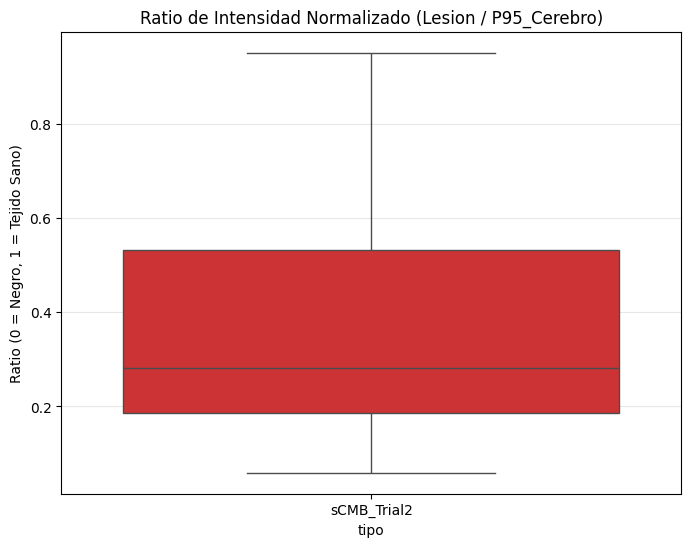

In [25]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import label, regionprops

# ========================= CONFIGURACIÓN =========================
# Dataset Real (CSIRO)
REAL_CSV = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/check2_nnUNet_results_test_with_rCMBs/analisis_intensidades_diagnostico.csv"
REAL_IMG_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/images"

# Dataset Sintético (Trial 2)
SYNTH_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/nnUNet_raw/Dataset112_SyntheticCMB"

OUTPUT_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/check2_nnUNet_results_test_with_rCMBs/auditoria_normalizada"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_p95_reference(img_data):
    """Calcula el percentil 95 del tejido cerebral (obviando el fondo)."""
    # Filtramos valores muy bajos (fondo/aire) para no sesgar el percentil
    brain_voxels = img_data[img_data > (np.mean(img_data) * 0.1)]
    return np.percentile(brain_voxels, 95) if len(brain_voxels) > 0 else 1.0

# 1. ANALIZAR RATIOS REALES
print("Calculando ratios para el dataset Real...")
df_real = pd.read_csv(REAL_CSV)
df_real = df_real[df_real['tipo'].isin(['TP', 'FN'])].copy()

real_ratios = []
# Cache de P95 por volumen para no repetir carga
p95_cache = {}

for idx, row in df_real.iterrows():
    subj = row['ID'].replace(".nii.gz", "")
    swi_path = os.path.join(REAL_IMG_DIR, f"{subj}_0000.nii.gz")
    
    if swi_path not in p95_cache:
        if os.path.exists(swi_path):
            img = nib.load(swi_path).get_fdata()
            p95_cache[swi_path] = get_p95_reference(img)
        else:
            continue
            
    p95 = p95_cache[swi_path]
    real_ratios.append({
        'tipo': 'Real (GT)',
        'ratio_intensidad': row['intensidad'] / p95
    })

# 2. ANALIZAR RATIOS SINTÉTICOS (TRIAL 2)
print("Calculando ratios para el dataset Sintético (Trial 2)...")
synth_img_dir = os.path.join(SYNTH_DIR, "imagesTr")
synth_lbl_dir = os.path.join(SYNTH_DIR, "labelsTr")
synth_files = os.listdir(synth_lbl_dir)[:15] # Muestra representativa

synth_ratios = []
for lbl_file in synth_files:
    img_file = lbl_file.replace(".nii.gz", "_0000.nii.gz")
    img_path = os.path.join(synth_img_dir, img_file)
    lbl_path = os.path.join(synth_lbl_dir, lbl_file)
    
    if os.path.exists(img_path) and os.path.exists(lbl_path):
        img_data = nib.load(img_path).get_fdata()
        lbl_data = nib.load(lbl_path).get_fdata()
        p95 = get_p95_reference(img_data)
        
        props = regionprops(label(lbl_data))
        for p in props:
            cx, cy, cz = map(int, p.centroid)
            val_centro = img_data[cx, cy, cz]
            synth_ratios.append({
                'tipo': 'sCMB_Trial2',
                'ratio_intensidad': val_centro / p95
            })

# 3. COMPARATIVA FINAL
df_comp = pd.concat([pd.DataFrame(real_ratios), pd.DataFrame(synth_ratios)], ignore_index=True)

plt.figure(figsize=(8, 6))
sns.boxplot(x='tipo', y='ratio_intensidad', data=df_comp, palette='Set1')
plt.axhline(df_comp[df_comp['tipo']=='Real (GT)']['ratio_intensidad'].median(), color='red', linestyle='--', alpha=0.5)
plt.title('Ratio de Intensidad Normalizado (Lesion / P95_Cerebro)')
plt.ylabel('Ratio (0 = Negro, 1 = Tejido Sano)')
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, "boxplot_normalizado.png"), dpi=300)

print("\n--- ESTADÍSTICAS DEL RATIO ---")
print(df_comp.groupby('tipo')['ratio_intensidad'].describe())